In [1]:
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Transformer

In [2]:

# new file with real station names
velocity_file = "../Data/whillans_events_with_velocity(in).csv"

df = pd.read_csv(
    velocity_file,
    parse_dates=["start_time"]
)

# Sort by time
df = df.sort_values("start_time").reset_index(drop=True)

print(df.shape)
df.head()

(5150, 627)


,start_time,stations,vx_la09_pre,vy_la09_pre,v_la09_pre,n_la09_pre,vx_la09_post,vy_la09_post,v_la09_post,n_la09_post,...,v_pre_ws04,vx_pre_ws04,vy_pre_ws04,v30d_ws04,n_pre_ws04,v_pre_ws05,vx_pre_ws05,vy_pre_ws05,v30d_ws05,n_pre_ws05
0,2008-01-25 01:01:00,"la09,slw1",NaN,NaN,NaN,0,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2008-01-25 18:14:00,"la09,slw1",NaN,NaN,NaN,0,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2008-01-26 15:56:00,"la09,slw1",NaN,NaN,NaN,0,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2008-01-27 02:47:00,"la09,slw1",NaN,NaN,NaN,0,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2008-01-27 16:04:00,"la09,slw1",NaN,NaN,NaN,0,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# These are the 30-day background velocity columns
v30d_cols = [c for c in df.columns if c.startswith("v30d_")]

print("Number of v30d station columns:", len(v30d_cols))
print(v30d_cols[:10])

Number of v30d station columns: 48
['v30d_gz01', 'v30d_gz02', 'v30d_gz03', 'v30d_gz04', 'v30d_gz05', 'v30d_gz06', 'v30d_gz07', 'v30d_gz08', 'v30d_gz09', 'v30d_gz10']


In [4]:
# Convert from wide format:
# one row per event, one column per station to long format:
# one row per event-station pair

df_long = df.melt(
    id_vars=["start_time"],
    value_vars=v30d_cols,
    var_name="station",
    value_name="velocity_30d"
)

# Clean station names so v30d_gz01 becomes gz01
df_long["station"] = df_long["station"].str.replace("v30d_", "", regex=False)

# Remove rows with missing velocity
df_long = df_long.dropna(subset=["velocity_30d"])

df_long.head()

,start_time,station,velocity_30d
1127,2011-01-16 11:15:00,gz01,359.000090
1128,2011-01-17 12:40:00,gz01,360.619359
1129,2011-01-17 22:05:00,gz01,360.619359
1130,2011-01-18 13:18:00,gz01,360.619359
1131,2011-01-19 13:55:00,gz01,360.619359


In [5]:
# Load official station coordinates
station_info = pd.read_csv("../Data/StationInformation.csv")

# Rename columns to simple names
station_info = station_info.rename(columns={
    "Station": "station",
    "Starting X (PS71) [m]": "x",
    "Starting Y (PS71) [m]": "y"
})

# Keep only needed columns
station_info = station_info[["station", "x", "y"]]

# Make station names lowercase to match df_long
station_info["station"] = station_info["station"].str.lower()

station_info.head()

,station,x,y
0,mg07,-185370.49,-558135.77
1,mg06,-189399.05,-570125.65
2,mg05,-185786.85,-565332.76
3,mg04,-182177.43,-560541.08
4,mg03,-180145.37,-557845.67


In [6]:
# Get the stations actually used in the velocity dataset
velocity_stations = sorted(df_long["station"].unique())

# Keep only station coordinates for stations used in the velocity data
station_coords = station_info[
    station_info["station"].isin(velocity_stations)
].copy()

print("Velocity stations:", len(velocity_stations))
print("Matched coordinate stations:", len(station_coords))

station_coords.head()

Velocity stations: 48
Matched coordinate stations: 48


,station,x,y
0,mg07,-185370.49,-558135.77
1,mg06,-189399.05,-570125.65
2,mg05,-185786.85,-565332.76
3,mg04,-182177.43,-560541.08
4,mg03,-180145.37,-557845.67


In [7]:
# Sort stations spatially using PS71 coordinates.


station_coords = station_coords.sort_values("y").reset_index(drop=True)

station_order = station_coords["station"].tolist()

print(station_order)

['gz09', 'gz10', 'gz11', 'gz01', 'gz02', 'gz03', 'gz04', 'gz20', 'gz05', 'gz06', 'gz07', 'gz16', 'gz08', 'gz17', 'gz15', 'gz14', 'gz19', 'gz12', 'gz18', 'gz13', 'la10', 'mg06', 'la03', 'mg05', 'ws04', 'ws05', 'la11', 'mg04', 'la02', 'slw1', 'la16', 'mg07', 'mg03', 'mg02', 'la13', 'la01', 'mg01', 'la15', 'la14', 'la06', 'la04', 'la07', 'la05', 'la08', 'la18', 'la09', 'la12', 'la17']


In [8]:
# Shared station colors for Figure 2 and Figure 4
station_colors = dict(
    zip(
        station_order,
        plt.get_cmap("turbo")(np.linspace(0, 1, len(station_order)))
    )
)

In [9]:
# Velocity grid 
velocity_grid_raw = df_long.pivot_table(
    index="start_time",
    columns="station",
    values="velocity_30d",
    aggfunc="mean"
)

# Use only stations with coordinate matches, in spatial order
velocity_grid_raw = velocity_grid_raw[station_order]

# Resample to daily spacing so the colormap does not have weird visual gaps
velocity_grid_daily = (
    velocity_grid_raw
    .resample("1D")
    .mean()
    .interpolate(method="time")
)

#  make display smoother
velocity_grid_plot = velocity_grid_daily.rolling(
    window=7,
    min_periods=1,
    center=True
).mean()

# Flip order so first spatial station appears at the top
velocity_grid_plot = velocity_grid_plot[velocity_grid_plot.columns[::-1]]

# Prepare plotting arrays
X_dates = velocity_grid_plot.index
Y_labels = velocity_grid_plot.columns
Z = velocity_grid_plot.values.T

print(Z.shape)

(48, 3654)


In [10]:

# Convert PS71 x/y coordinates back to longitude/latitude
polar_to_geo = Transformer.from_crs("EPSG:3031", "EPSG:4326", always_xy=True)

station_coords = station_coords.copy()

station_coords["lon"], station_coords["lat"] = polar_to_geo.transform(
    station_coords["x"].values,
    station_coords["y"].values
)

station_coords.head()

,station,x,y,lon,lat
0,gz09,-171770.02,-614891.78,-164.392294,-84.129014
1,gz10,-166013.97,-613443.20,-164.856975,-84.155848
2,gz11,-160292.35,-611963.36,-165.322185,-84.182493
3,gz01,-178910.25,-610613.52,-163.669373,-84.148741
4,gz02,-173210.48,-609188.43,-164.127964,-84.175824


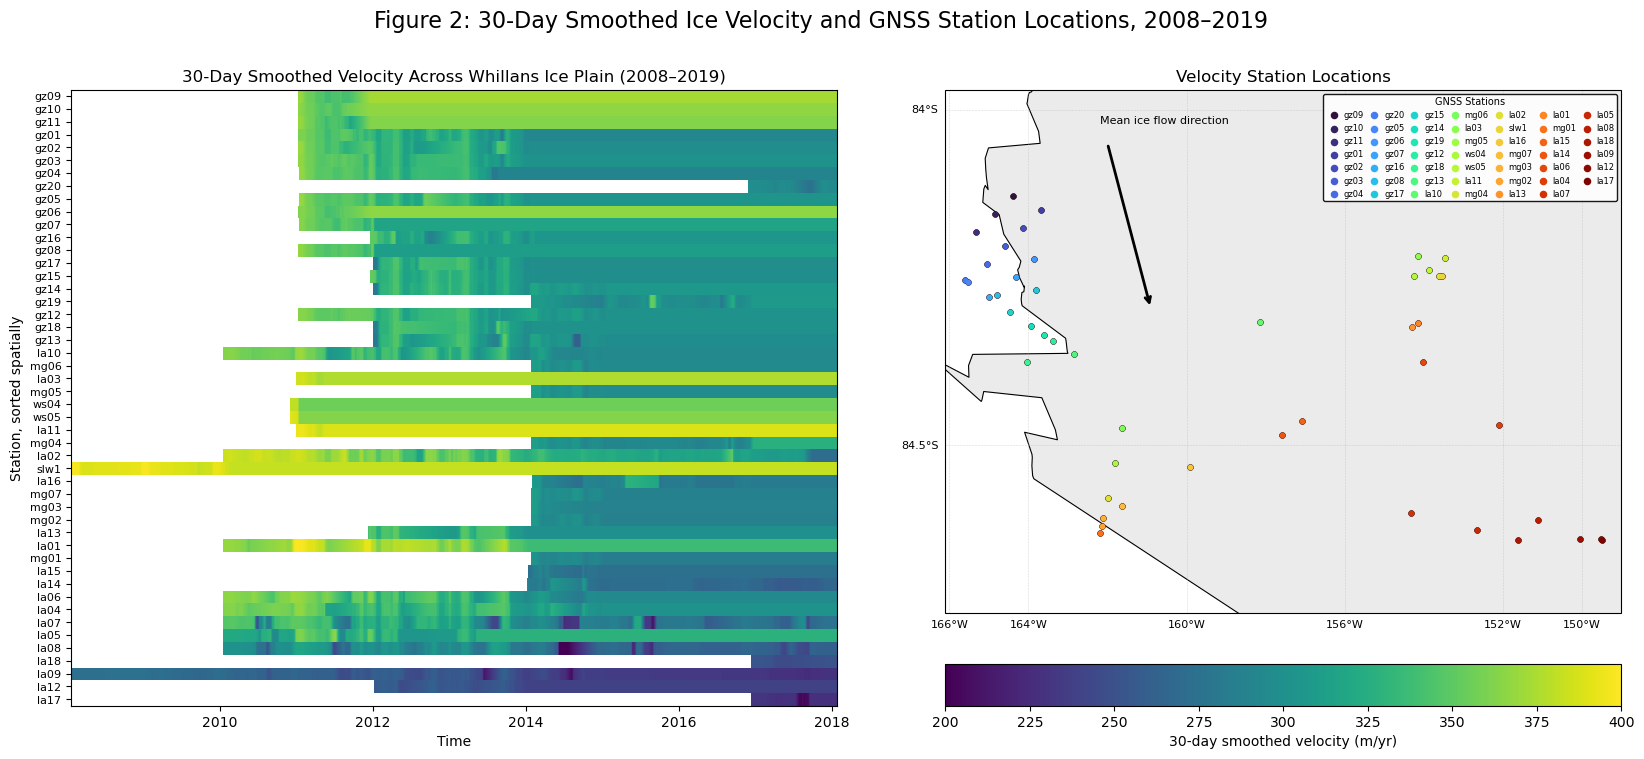

In [11]:
# Projection for the map
map_proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(20, 8))

fig.suptitle(
    "Figure 2: 30-Day Smoothed Ice Velocity and GNSS Station Locations, 2008–2019",
    fontsize=16,
    y=0.98
)


# Layout:
# left = colormap
# right top = cartomap
# right bottom = colorbar
gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    width_ratios=[1.7, 1.5],
    height_ratios=[1.5, 0.12],
    wspace=0.15,
    hspace=0.18
)

# left panel: velocity heatmap

ax1 = fig.add_subplot(gs[:, 0])

im = ax1.imshow(
    Z,
    aspect="auto",
    interpolation="nearest",
    origin="lower",
    extent=[
        mdates.date2num(X_dates.min()),
        mdates.date2num(X_dates.max()),
        -0.5,
        len(Y_labels) - 0.5
    ],
    cmap="viridis",
    vmin=200,
    vmax=400
)

ax1.set_yticks(range(len(Y_labels)))
ax1.set_yticklabels(Y_labels, fontsize=8)

ax1.xaxis_date()
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_major_locator(mdates.YearLocator(2))

ax1.set_xlabel("Time")
ax1.set_ylabel("Station, sorted spatially")
ax1.set_title("30-Day Smoothed Velocity Across Whillans Ice Plain (2008–2019)")


# right panel: Cartopy map

ax2 = fig.add_subplot(gs[0, 1], projection=map_proj)

ax2.add_feature(cfeature.LAND, facecolor="0.92")
ax2.coastlines(linewidth=0.8)

ax2.scatter(
    station_coords["lon"],
    station_coords["lat"],
    s=18,
    color="red",
    edgecolor="black",
    linewidth=0.4,
    transform=ccrs.PlateCarree(),
    zorder=5
)



for _, row in station_coords.iterrows():
    station = row["station"]
    color = station_colors[station]

    ax2.scatter(
        row["lon"],
        row["lat"],
        s=10,
        color=color,
        transform=ccrs.PlateCarree(),
        zorder=5,
        label=station
    )

# Add boxed legend
legend = ax2.legend(
    title="GNSS Stations",
    loc="upper right",
    ncol=7,                # split into two columns
    fontsize=6,
    title_fontsize=7,
    frameon=True,
    markerscale=1.4,       #  smaller dots in legend
    borderpad=0.3,
    columnspacing=0.2,     # spacing between columns
    handletextpad=0.2
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("black")
legend.get_frame().set_alpha(0.9)

# Creating the cartopy map to show how the stations vary across the ice plain 

ax2.set_aspect("auto")

ax2.set_extent(
    [-166.1, -149.0, -84.75, -83.97],
    crs=ccrs.PlateCarree()
)


# Mean ice flow direction arrow


import numpy as np

# Mean velocity components
mean_vx = 263.55026005936827
mean_vy = -168.9895926697143

# Normalize vector so only direction is used
mag = np.sqrt(mean_vx**2 + mean_vy**2)

dx = mean_vx / mag
dy = mean_vy / mag

# Arrow starting point
x0 = -162.0
y0 = -84.05

# Arrow length
scale = 1.3

# Arrow ending point
x1 = x0 + dx * scale
y1 = y0 + dy * scale * 0.35  

# Draw arrow
ax2.annotate(
    "",
    xy=(x1, y1),
    xytext=(x0, y0),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=2,
        color="black"
    ),
    transform=ccrs.PlateCarree(),
    zorder=10
)

# Label
ax2.text(
    x0 - 0.2,
    y0 + 0.03,
    "Mean ice flow direction",
    fontsize=8,
    transform=ccrs.PlateCarree(),
    zorder=10
)

gl = ax2.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.4,
    linestyle="--",
    alpha=0.5,
    xlocs=[-166, -164, -160, -156, -152, -150, -148],
    ylocs=[-84.5, -84.0,]
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}

ax2.set_title("Velocity Station Locations")


# Creating the colorbar 

cax = fig.add_subplot(gs[1, 1])

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal"
)

cbar.set_label("30-day smoothed velocity (m/yr)")



plt.savefig(
    "../figures/figure2_velocity_colormesh_cartopy_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Figure 2 Interpertation

Figure 2 shows the spatial distribution of GNSS stations (right panel) and a colormesh of 30-day smoothed ice velocity at those stations from 2008 to 2019 (left panel). Each row represents a station ordered spatially, and color indicates velocity, with warmer colors showing higher values.

Overall, there is a clear decrease in velocity over time across most stations. Velocities are generally higher earlier in the record (around 2008–2012) and become lower and more uniform after about 2013–2014, indicating a broad slowdown of the ice plain. Some spatial variability is also evident, with certain stations consistently showing higher or lower velocities, likely reflecting their positions within the ice flow system.

White gaps in the colormesh represent missing data, but the overall trend of decreasing velocity across the Whillans Ice Plain is still clear.